In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [198]:
data = pd.read_csv('../artifacts/sentiment_analysis.csv')

In [199]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


Data Preprocess

In [200]:
data.shape

(7920, 3)

In [70]:
data.duplicated().sum()

np.int64(0)

In [71]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

Text Preprocessing

In [201]:
import re
import string

In [80]:
#CONVERT UPPER CASE TO LOWERCASE 
data['tweet'].head

<bound method NDFrame.head of 0       #fingerprint #pregnancy test  #android #apps #...
1       finally a transparant silicon case ^^ thanks t...
2       we love this! would you go? #talk #makememorie...
3       i'm wired i know i'm george i was made that wa...
4       what amazing service! apple won't even talk to...
                              ...                        
7915    live out loud #lol #liveoutloud #selfie #smile...
7916    we would like to wish you an amazing day! make...
7917    helping my lovely 90 year old neighbor with he...
7918    finally got my #smart #pocket #wifi stay conne...
7919    apple barcelona!!! #apple #store #bcn #barcelo...
Name: tweet, Length: 7920, dtype: str>

In [202]:
data['tweet'] = data['tweet'].apply(lambda x: " ".join(x.lower() for x in x.split()))

In [112]:
data['tweet'].head(3)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
Name: tweet, dtype: str

In [203]:
#REMOVE lINKS
data['tweet'] = data['tweet'].apply(lambda x: " ".join(re.sub(r'^https?:\/\/.*[\r\n]*','',x,flags=re.MULTILINE) for x in x.split()))

In [83]:
data['tweet'].head(5)

0    #fingerprint #pregnancy test #android #apps #b...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: str

In [204]:
#REMOVE PUNCTUATIONS
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation,'')
    return text

data['tweet'] = data['tweet'].apply(remove_punctuations)

In [114]:
data['tweet'].head(5)

0    fingerprint pregnancy test httpsgooglh1mfqv an...
1    finally a transparant silicon case  thanks to ...
2    we love this would you go talk makememories un...
3    im wired i know im george i was made that way ...
4    what amazing service apple wont even talk to m...
Name: tweet, dtype: str

In [205]:
#REMOVE NUMBERS
data['tweet'] = data['tweet'].str.replace(r'\d+','',regex=True)

In [116]:
data['tweet']

0       fingerprint pregnancy test httpsgooglhmfqv and...
1       finally a transparant silicon case  thanks to ...
2       we love this would you go talk makememories un...
3       im wired i know im george i was made that way ...
4       what amazing service apple wont even talk to m...
                              ...                        
7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely  year old neighbor with her ...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, Length: 7920, dtype: str

In [206]:
#REMOVE STOPWORDS
import nltk

In [207]:
nltk.download('stopwords',download_dir='../static/model/')

[nltk_data] Downloading package stopwords to ../static/model/...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [208]:
with open('../static/model/corpora/stopwords/english','r') as file:
    sw = file.read().splitlines()

In [209]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [210]:
data['tweet'] =  data['tweet'].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

In [211]:
data['tweet'].head()

0    fingerprint pregnancy test android apps beauti...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
Name: tweet, dtype: str

In [212]:
#STEMMING
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [213]:
data['tweet'] =  data['tweet'].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [126]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test httpsgooglhmfqv andr...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


In [214]:
#BUILDING VOCABULARY
from collections import Counter
vocab = Counter()

In [215]:
for sentence in data['tweet']:
    vocab.update(sentence.split())

In [216]:
data.shape

(7920, 3)

In [217]:
#OVERFITING AND UNNDERFITTING CONTROL
tokens  = [key for key in vocab if vocab[key] > 10]

In [218]:
len(tokens)

1145

In [219]:
def save_vocabulary(lines,filename):
     data  = '\n'.join(lines)
     file = open(filename,'w',encoding='utf-8')
     file.write(data)
     file.close()
save_vocabulary(tokens,'../static/model/vocabulary.txt')

In [220]:
#DIVEDE DATASET 
x = data['tweet']
y = data['label']

In [221]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [222]:
X_train

697     appl though big phone unus … appl hypocrit iph...
2191    tv review cameron crowe’ ‘roadies’ news photog...
2790                 justinbieb appl ipad iphon may ammay
116     fanta appl fanta delish sunday sundayfunday he...
4239    thank u elect make use smartphon tablet way us...
                              ...                        
3721    michel came home tcot nascar theater movi sing...
6957            feel weaker mum give dose appleit medicin
5946                  lost contact pleas text add everyon
5359    love tobi cat cute sweet awww amaz cat hashtag...
1660    gain follow rt must follow follow back follow ...
Name: tweet, Length: 6336, dtype: str

In [223]:
#VECTORIZATION
def vectorization(ds,vocabulary):
    vectorized_list = []

    for sentence in ds:
        sentence_list = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_list[i] = 1
                
        vectorized_list.append(sentence_list)
    vectorized_list_new =  np.asarray(vectorized_list,dtype=np.float32)
    return vectorized_list_new

In [224]:
vectorized_x_train = vectorization(X_train, tokens)

In [225]:
vectorized_x_test = vectorization(X_test, tokens)

In [226]:
y_train.value_counts()

label
0    4700
1    1636
Name: count, dtype: int64

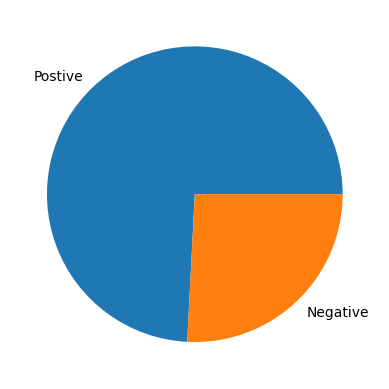

In [227]:
plt.pie(np.array([y_train.value_counts()[0],y_train.value_counts()[1]]),labels=['Postive','Negative'])
plt.show()

In [229]:
#HANDLE IMBALANCE DATASET
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train,y_train)
print(vectorized_x_train_smote.shape,y_train_smote.shape)

(9400, 1145) (9400,)


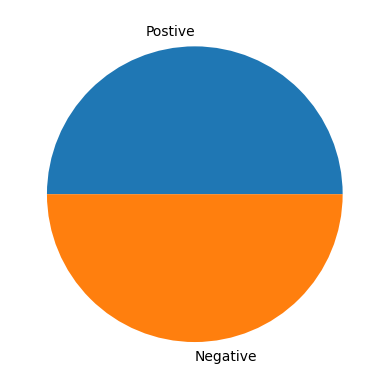

In [234]:
plt.pie(np.array([y_train_smote.value_counts()[0],y_train_smote.value_counts()[1]]),labels=['Postive','Negative'])
plt.show()

In [238]:
#MODEL TRAINING AND EVALUATION 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [250]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act,y_pred), 3)
    pr = round(precision_score(y_act,y_pred), 3)
    rec = round(recall_score(y_act,y_pred), 3) 
    f1 = round(f1_score(y_act,y_pred), 3)
    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act,y_pred), 3)
    pr = round(precision_score(y_act,y_pred), 3)
    rec = round(recall_score(y_act,y_pred), 3) 
    f1 = round(f1_score(y_act,y_pred), 3)
    print(f'Testing Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

In [251]:
#LOGISTIC REGRESSION
lr = LogisticRegression()
lr.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred  = lr.predict(vectorized_x_train_smote)
y_test_pred  = lr.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy = 0.939
	Precision = 0.914
	Recall = 0.97
	F1-Score = 0.941
Testing Scores:
	Accuracy = 0.87
	Precision = 0.692
	Recall = 0.851
	F1-Score = 0.763


In [252]:
#NAIVE BAYES
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred  = mnb.predict(vectorized_x_train_smote)
y_test_pred  = mnb.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy = 0.905
	Precision = 0.868
	Recall = 0.954
	F1-Score = 0.909
Testing Scores:
	Accuracy = 0.865
	Precision = 0.665
	Recall = 0.908
	F1-Score = 0.768


In [253]:
#DESICION TREE
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred  = dt.predict(vectorized_x_train_smote)
y_test_pred  = dt.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.818
	Precision = 0.626
	Recall = 0.644
	F1-Score = 0.635


In [254]:
#RANDOM FOREST
rf = RandomForestClassifier()
rf.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred  = rf.predict(vectorized_x_train_smote)
y_test_pred  = rf.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.872
	Precision = 0.747
	Recall = 0.728
	F1-Score = 0.738


In [255]:
#SUPPORT VECTOR MACHINE
svm = SVC()
svm.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred  = svm.predict(vectorized_x_train_smote)
y_test_pred  = svm.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy = 0.978
	Precision = 0.96
	Recall = 0.997
	F1-Score = 0.978
Testing Scores:
	Accuracy = 0.881
	Precision = 0.728
	Recall = 0.823
	F1-Score = 0.773


In [256]:
import pickle
with open('../static/model/model.pickle','wb') as file:
    pickle.dump(lr,file)